In [1]:
%matplotlib inline

# Businesses

* **Input**: cleaned and optimized pickeled DataFrames (businesses.csv) for 20XX
* **Output**: Visualisations

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#ZoneId-to-MS-Region-Mapping" data-toc-modified-id="ZoneId-to-MS-Region-Mapping-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>ZoneId to MS-Region Mapping</a></span></li><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>SynPop</a></span></li></ul></li><li><span><a href="#Analysis" data-toc-modified-id="Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#Globally" data-toc-modified-id="Globally-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Globally</a></span></li><li><span><a href="#By-Sector" data-toc-modified-id="By-Sector-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>By Sector</a></span></li><li><span><a href="#By-Canton" data-toc-modified-id="By-Canton-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>By Canton</a></span></li><li><span><a href="#By-MS-Region" data-toc-modified-id="By-MS-Region-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>By MS-Region</a></span></li></ul></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

In [2]:
import logging
import os
import sys

import pandas as pd
import geopandas as gpd

from matplotlib import pyplot as plt

In [3]:
sys.path.append(r'\\Filer16L\P-V160L\SIMBA.A11244\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop import visualisations
import synpop.utils as utils

##  Settings

In [5]:
YEAR_IST = 2017
YEAR = 2030

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_BUSINESSES_FILE_IST = os.path.join(DATA_DIR_IST, 'businesses_{}.pickle.gzip'.format(YEAR_IST))

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2030\02_preprocessed'
SYNPOP_BUSINESSES_FILE = os.path.join(DATA_DIR, 'businesses_{}.pickle.gzip'.format(YEAR))

MOBI_ZONES_SHP = r'\\Filer16L\P-V160L\SIMBA.A11244\10_Daten\72_NPVM\2016\20_NPVM2016_Daten\02-LV95_NPVM_7978_Verkehrszonen_20171120\NPVM_Verkehrszonen.shp'

**Plot Export Settings**

In [6]:
SAVE_FIGURES = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [7]:
utils.create_dir(OUTPUT_DIR)

2020-02-18 10:19:41,972 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

###  ZoneId to MS-Region Mapping

In [8]:
zones = gpd.read_file(MOBI_ZONES_SHP)

In [9]:
ms_region_mapping = (zones[['ID', 'N_MSR']]
                     .astype({'ID': int})
                     .fillna('None')
                     .rename(columns={'ID':'location_id', 'N_MSR':'ms_region'})
                     .set_index('location_id')
                     .iloc[:,0]
                     .to_dict()                
                    )

### SynPop

In [10]:
SYNPOP_BUSINESSES_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2030\\02_preprocessed\\businesses_2030.pickle.gzip'

In [11]:
%%time
businesses = pd.read_pickle(SYNPOP_BUSINESSES_FILE, compression='gzip') 
businesses['ms_region'] = businesses['location_id'].map(ms_region_mapping)
businesses['ms_region'] = businesses['ms_region'].fillna('_Null_')

Wall time: 1.73 s


In [12]:
SYNPOP_BUSINESSES_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\businesses_2017.pickle.gzip'

In [13]:
%%time
businesses_ist = pd.read_pickle(SYNPOP_BUSINESSES_FILE_IST, compression='gzip') 
businesses_ist['ms_region'] = businesses_ist['location_id'].map(ms_region_mapping)
businesses_ist['ms_region'] = businesses_ist['ms_region'].fillna('_Null_')

Wall time: 1.06 s


## Analysis

In [14]:
businesses.head()

,business_id,location_id,sector,legal_form,noga_code,jobs_ch,fte_ch,jobs_cb,fte_cb,nr_of_cars,...,xcoord,ycoord,bcoord_type,year_of_foundation,KT,N_KT,ID_Gem,N_Gem,KT_full,ms_region
0,4,105201003,agriculture,partnerships,16200,1,0.89,0,0.0,0,...,2668716.0,1215690.0,not_available,2016,3.0,LU,1052.0,Buchrain,Luzern,Luzern
1,5,643201001,agriculture,partnerships,14300,1,0.50,0,0.0,0,...,2539429.0,1205253.0,not_available,2014,24.0,NE,6432.0,La Brévine,Neuchâtel,La Chaux-de-Fonds
2,6,664101002,services fC,companies,813000,7,6.39,0,0.0,2,...,2500207.0,1113309.0,not_available,2007,25.0,GE,6641.0,Troinex,Genève,Genève
3,7,469101004,services fC,companies,0,3,2.17,0,0.0,3,...,2735443.0,1276437.0,not_available,1995,20.0,TG,4691.0,Münsterlingen,Thurgau,Untersee
4,10,662101098,services fC,branch_establishment,813000,4,3.20,1,0.8,0,...,2500902.0,1117633.0,not_available,2011,25.0,GE,6621.0,Genève,Genève,Genève


In [15]:
businesses_ist.head()

,business_id,location_id,sector,legal_form,noga_code,jobs_ch,fte_ch,jobs_cb,fte_cb,nr_of_cars,...,xcoord,ycoord,bcoord_type,year_of_foundation,KT,N_KT,ID_Gem,N_Gem,KT_full,ms_region
0,1,32901011,agriculture,partnerships,11300,3,3.00,0,0.0,0,...,2627400.0,1229230.0,not_available,1995,2.0,BE,329.0,Langenthal,Bern / Berne,Oberaargau
1,2,115101001,other services,partnerships,960900,3,1.88,0,0.0,1,...,2640938.0,1218834.0,not_available,1994,3.0,LU,1151.0,Willisau,Luzern,Willisau
2,3,74601002,agriculture,partnerships,16100,1,0.38,0,0.0,0,...,2591729.0,1221704.0,not_available,1994,2.0,BE,746.0,Safnern,Bern / Berne,Biel/Bienne
3,4,105201003,agriculture,partnerships,16200,1,0.89,0,0.0,0,...,2668716.0,1215690.0,not_available,2016,3.0,LU,1052.0,Buchrain,Luzern,Luzern
4,5,643201001,agriculture,partnerships,14300,1,0.50,0,0.0,0,...,2539429.0,1205253.0,not_available,2014,24.0,NE,6432.0,La Brévine,Neuchâtel,La Chaux-de-Fonds


### Globally

In [16]:
def compute_stats_summary(df_ist, df_scenario, year_ist, year_scenario):
    stats_list = []
    for df, year in zip((df_ist, df_scenario), (year_ist,  year_scenario)):
        stats = (df.agg({'business_id': 'count',
                         'jobs_ch':sum, 
                         'jobs_cb':sum,
                         'fte_ch':sum,
                         'fte_cb':sum}
                        )
                   .rename(index={'business_id': 'businesses'})
                   .astype(int)
                ) 
        stats.loc['total_jobs'] = stats.loc['jobs_ch'] + stats.loc['jobs_cb']
        stats.loc['total_fte'] = stats.loc['fte_ch'] + stats.loc['fte_cb'] 
        stats = stats.rename(year)
        stats_list.append(stats)
    
    stats_summary = pd.concat(stats_list, axis=1)
    stats_summary['% change'] = ((stats_summary[year_scenario] - stats_summary[year_ist]) / stats_summary[year_scenario] * 100).astype(int)

    return stats_summary


**Businesses & Schools**

In [17]:
businesses.head(0)

,business_id,location_id,sector,legal_form,noga_code,jobs_ch,fte_ch,jobs_cb,fte_cb,nr_of_cars,...,xcoord,ycoord,bcoord_type,year_of_foundation,KT,N_KT,ID_Gem,N_Gem,KT_full,ms_region


In [18]:
stats_summary = compute_stats_summary(businesses_ist, businesses, YEAR_IST, YEAR)
stats_summary

2020-02-18 10:19:46,642 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


,2017,2030,% change
businesses,680100,1230484,44
jobs_ch,4827239,5918698,18
jobs_cb,293096,291543,0
fte_ch,3755128,5377450,30
fte_cb,245932,258542,4
total_jobs,5120335,6210241,17
total_fte,4001060,5635992,29


**Businesses without Schools**

In [19]:
stats_summary = compute_stats_summary(businesses_ist.query('school_type == "no_school"'),
                                      businesses.query('school_type == "no_school"'),
                                      YEAR_IST, YEAR
                                     )
stats_summary

,2017,2030,% change
businesses,650028,1215065,46
jobs_ch,4506216,5759273,21
jobs_cb,275358,279877,1
fte_ch,3555018,5278617,32
fte_cb,233914,250826,6
total_jobs,4781574,6039150,20
total_fte,3788932,5529443,31


**Schools**

In [20]:
def compute_school_summary(df_ist, df_scenario, year_ist, year_scenario):
    stats_list = []
    for df, year in zip((df_ist, df_scenario), (year_ist,  year_scenario)):
        stats = (df.query('school_type != "no_school"')
                   .groupby('school_type', observed=True)['business_id'].count()
                   .rename(year)
                 
                )
        stats.index = stats.index.tolist()
        stats.loc['TOTAL'] = stats.sum()
    
        stats_list.append(stats)
    
    stats_summary = pd.concat(stats_list, axis=1)
    stats_summary['% change'] = ((stats_summary[year_scenario] - stats_summary[year_ist]) / stats_summary[year_scenario] * 100).astype(int)

    return stats_summary

In [21]:
school_stats = compute_school_summary(businesses_ist, businesses, YEAR_IST, YEAR)
school_stats

,2017,2030,% change
other,16867,8517,-98
primary,10169,5290,-92
secondary,2068,1102,-87
other_higher_education,266,132,-101
university,702,378,-85
TOTAL,30072,15419,-95


2020-02-18 10:19:48,229 - INFO - root: Figure saved to file : ./outputs\11-01_SynPop2017_vs_SynPop2030_number_of_schools.png


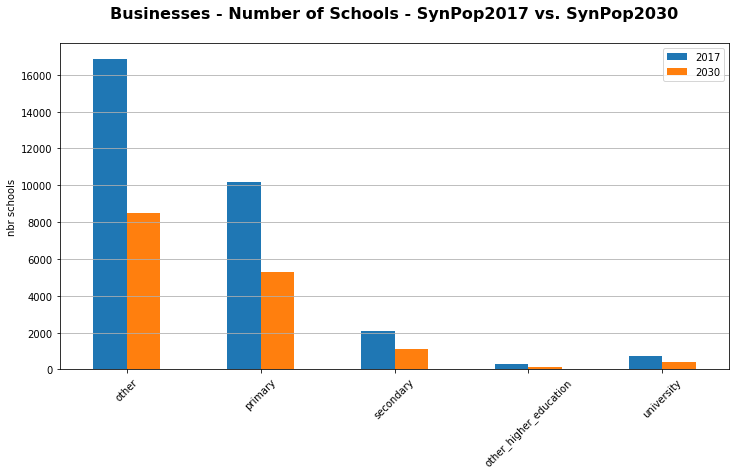

In [22]:
title = 'Businesses - Number of Schools - SynPop{year_ist} vs. SynPop{year}'.format(year_ist=YEAR_IST, year=YEAR)

ax = school_stats.iloc[:-1, :2].plot.bar(figsize=(12, 6), rot=45)
_ = plt.grid(axis='y')
_ = ax.set_ylabel('nbr schools')
_ = ax.set_xlabel('')
_ = ax.set_title(title, pad=25, fontdict={'fontsize': 16, 'fontweight': 'bold'})

if SAVE_FIGURES:
    fig_file_name = '11-01_SynPop{}_vs_SynPop{}_number_of_schools.{}'.format(YEAR_IST, YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

### By Sector

In [23]:
businesses_ist.columns

Index(['business_id', 'location_id', 'sector', 'legal_form', 'noga_code',
       'jobs_ch', 'fte_ch', 'jobs_cb', 'fte_cb', 'nr_of_cars', 'school_type',
       'xcoord', 'ycoord', 'bcoord_type', 'year_of_foundation', 'KT', 'N_KT',
       'ID_Gem', 'N_Gem', 'KT_full', 'ms_region'],
      dtype='object')

In [24]:
del visualisations

In [25]:
from synpop import visualisations

In [26]:
stats_per_sector = visualisations.get_businesses_comparison_summary_by_category(businesses_ist, businesses, 
                                                                                YEAR_IST, YEAR, 
                                                                                query='school_type == "no_school"', 
                                                                                agg_column='sector'
                                                                                )

2020-02-18 10:19:50,491 - INFO - root: Figure saved to file : ./outputs\11-02a_SynPop2017_vs_SynPop2030_total_businesses_per_sector.png


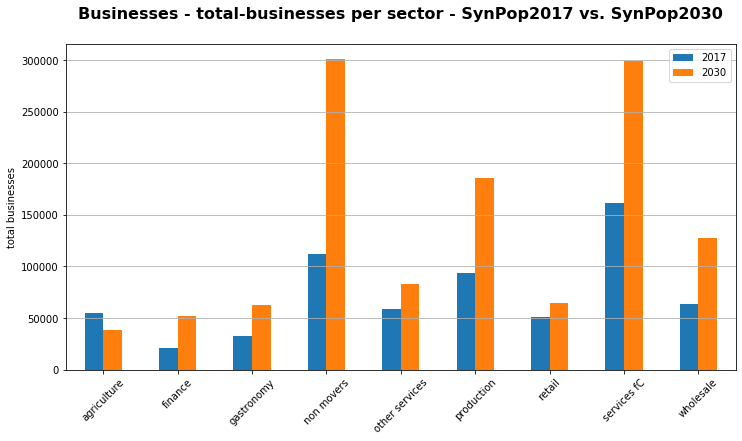

In [27]:
category = 'sector'
query='school_type == "no_school"'
statistic = 'total_businesses'
title = ('Businesses - {statistic} per {category} - SynPop{year_ist} vs. SynPop{year}'
         .format(year_ist=YEAR_IST, year=YEAR, statistic=statistic, category=category)
         .replace('_', '-')
        )

ax = visualisations.plot_businesses_comparison_by_category(businesses_ist, businesses,
                                                           YEAR_IST, YEAR, 
                                                           statistic=statistic,
                                                           query=query, 
                                                           agg_column=category,
                                                           title=title
                                                          )

if SAVE_FIGURES:
    fig_file_name = '11-02a_SynPop{}_vs_SynPop{}_{}_per_{}.{}'.format(YEAR_IST, YEAR, statistic,
                                                                                              category, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

2020-02-18 10:19:52,029 - INFO - root: Figure saved to file : ./outputs\11-02b_SynPop2017_vs_SynPop2030_total_jobs_per_sector.png


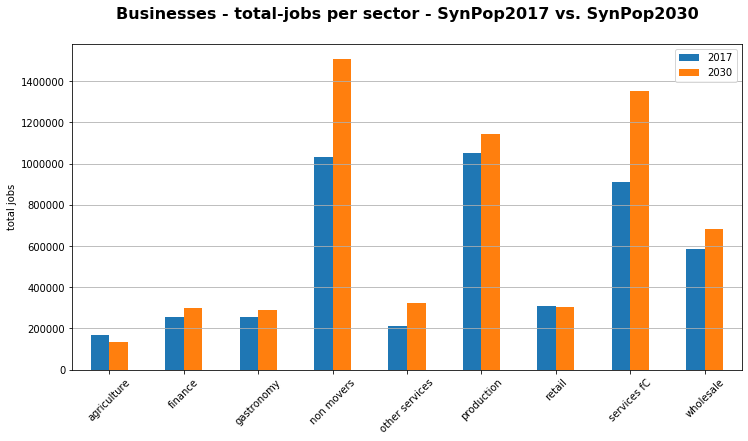

In [28]:
category = 'sector'
query='school_type == "no_school"'
statistic = 'total_jobs'
title = ('Businesses - {statistic} per {category} - SynPop{year_ist} vs. SynPop{year}'
         .format(year_ist=YEAR_IST, year=YEAR, statistic=statistic, category=category)
         .replace('_', '-')
        )

ax = visualisations.plot_businesses_comparison_by_category(businesses_ist, businesses,
                                                           YEAR_IST, YEAR, 
                                                           statistic=statistic,
                                                           query=query, 
                                                           agg_column=category,
                                                           title=title
                                                          )

if SAVE_FIGURES:
    fig_file_name = '11-02b_SynPop{}_vs_SynPop{}_{}_per_{}.{}'.format(YEAR_IST, YEAR, statistic,
                                                                                              category, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

2020-02-18 10:19:53,534 - INFO - root: Figure saved to file : ./outputs\11-02c_SynPop2017_vs_SynPop2030_total_fte_per_sector.png


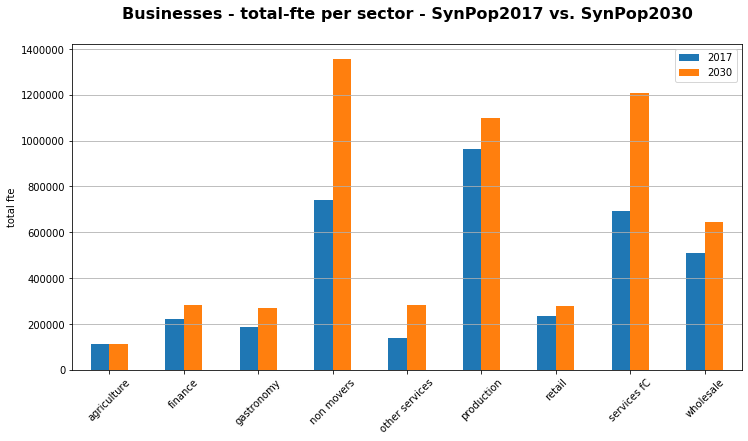

In [29]:
category = 'sector'
query='school_type == "no_school"'
statistic = 'total_fte'
title = ('Businesses - {statistic} per {category} - SynPop{year_ist} vs. SynPop{year}'
         .format(year_ist=YEAR_IST, year=YEAR, statistic=statistic, category=category)
         .replace('_', '-')
        )

ax = visualisations.plot_businesses_comparison_by_category(businesses_ist, businesses,
                                                           YEAR_IST, YEAR, 
                                                           statistic=statistic,
                                                           query=query, 
                                                           agg_column=category,
                                                           title=title
                                                          )

if SAVE_FIGURES:
    fig_file_name = '11-02c_SynPop{}_vs_SynPop{}_{}_per_{}.{}'.format(YEAR_IST, YEAR, statistic,
                                                                                              category, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

### By Canton

In [30]:
stats_per_canton = visualisations.get_businesses_comparison_summary_by_category(businesses_ist, businesses, 
                                                                                YEAR_IST, YEAR, 
                                                                                query='school_type == "no_school"', 
                                                                                agg_column='N_KT'
                                                                                )

In [31]:
stats_per_canton

2017     2030  % change
N_KT statistic                                  
AG   fte_cb             11170    11299         1
     fte_ch            242825   323333        24
     jobs_cb            12886    12714        -1
     jobs_ch           305297   351807        13
     total_businesses   43069    73714        41
...                       ...      ...       ...
ZH   jobs_cb             7598     7376        -3
     jobs_ch           927064  1047666        11
     total_businesses  111890   210005        46
     total_fte         739357   969127        23
     total_jobs        934662  1055042        11

[182 rows x 3 columns]

### By MS-Region

In [32]:
stats_per_msr = visualisations.get_businesses_comparison_summary_by_category(businesses_ist, businesses, 
                                                                             YEAR_IST, YEAR, 
                                                                             query='school_type == "no_school"', 
                                                                             agg_column='ms_region'
                                                                             )

**Total Businesses**

In [33]:
stats_per_msr.query('statistic == "total_businesses"').reset_index(level=1, drop=True).sort_values(YEAR, ascending=False)

,2017,2030,% change
ms_region,,,
Zürich,42315,90707,53
Genève,38624,82177,52
Bern,23828,54597,56
Lausanne,20494,42636,51
Basel-Stadt,16350,33171,50
...,...,...,...
Mesolcina,1133,1106,-2
Schanfigg,534,817,34
Pays d'Enhaut,547,661,17


**Total Jobs**

In [34]:
stats_per_msr.query('statistic == "total_jobs"').reset_index(level=1, drop=True).sort_values(YEAR, ascending=False)

,2017,2030,% change
ms_region,,,
Zürich,426772,471804,9
Genève,323205,428166,24
Bern,264076,299421,11
Lausanne,183460,223201,17
Basel-Stadt,174881,185404,5
...,...,...,...
Mesolcina,3888,4210,7
Schanfigg,2943,3334,11
Goms,2547,2676,4


**Total Full Time Equivalent**

In [35]:
stats_per_msr.query('statistic == "total_fte"').reset_index(level=1, drop=True).sort_values(YEAR, ascending=False)

,2017,2030,% change
ms_region,,,
Zürich,338001,432777,21
Genève,270601,395636,31
Bern,203562,271518,25
Lausanne,148152,205959,28
Basel-Stadt,140230,169417,17
...,...,...,...
Mesolcina,3042,3848,20
Schanfigg,2387,3135,23
Goms,1925,2356,18


## Export Notebook to HTML

In [36]:
### Write notebook to a html file
!jupyter nbconvert --to html 11_Businesses.ipynb

[NbConvertApp] Converting notebook 11_Businesses.ipynb to html
[NbConvertApp] Writing 336498 bytes to 11_Businesses.html
